# 08 — Marketing Analytics (adapted to available data)

**Phase 10.**

# ⚠️ This is NOT multi-channel marketing attribution

**This dataset contains no marketing data whatsoever.** There are no campaigns, channels, ad spend,
impressions, clicks, sessions, referrers, UTM parameters, landing pages or first-touch records.

Therefore **nothing in this notebook is attribution**, and none of it can produce:

| Standard marketing metric | Why it is impossible here |
|---|---|
| Customer acquisition cost (CAC) | no spend data of any kind |
| Return on ad spend (ROAS) | no spend, no campaign linkage |
| Channel contribution / mix | no channel field on any table |
| First-touch / last-touch / multi-touch attribution | no touchpoint or session data |
| Conversion rate | no visit or session counts — only completed orders exist |
| Campaign lift | no campaign identifiers, no exposure flags |

**What this notebook does instead.** It analyses the dimensions that *do* exist and that a
marketing team could act on — **payment method, instalment behaviour, customer region, seller, and
category mix**. These describe **where and how demand converts**, never **where it came from**.
They are performance *segments*, not channels, and the distinction is maintained throughout.

Section 6 sets out exactly what data would be needed to do this properly.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path("..").resolve()))
from src.viz import *
apply_style()

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

PROC = Path("..") / "data" / "processed"
fct_orders = pd.read_parquet(PROC / "fct_orders.parquet")
fct_items = pd.read_parquet(PROC / "fct_order_items.parquet")

# The analysis base fixed in Phase 3: delivered orders inside the usable window.
orders = fct_orders[fct_orders.is_delivered & fct_orders.in_window].copy()
items = fct_items[(fct_items.is_delivered == True) & (fct_items.in_window == True)].copy()

print(f"orders   : {len(orders):,}  (delivered, Jan-2017..Aug-2018)")
print(f"items    : {len(items):,}")
print(f"revenue  : R$ {orders.order_revenue.sum():,.2f}")
print(f"customers: {orders.customer_unique_id.nunique():,}")


payments = pd.read_parquet(PROC / "payments_clean.parquet")
print(f"\npayment records: {len(payments):,}")
print(f"valid payments : {int(payments.is_valid_payment.sum()):,}")

orders   : 96,211  (delivered, Jan-2017..Aug-2018)
items    : 109,880
revenue  : R$ 13,181,027.13
customers: 93,104

payment records: 103,886
valid payments : 103,877


## 1. Payment method as a customer-segment proxy

Payment method is the closest thing in this data to a behavioural segment: it reflects access to
credit, purchasing power and risk appetite. It is **not** a channel — the customer chose it at
checkout, after arriving by some unknown route.

In [2]:
pay_view = orders.dropna(subset=["payment_type"]).copy()

by_payment = pay_view.groupby("payment_type", observed=True).agg(
    orders_n=("order_id", "count"),
    revenue=("order_revenue", "sum"),
    aov=("order_revenue", "mean"),
    median_value=("order_revenue", "median"),
    avg_items=("n_items", "mean"),
    avg_review=("review_score", "mean"),
    avg_installments=("max_installments", "mean")).sort_values("revenue", ascending=False)
by_payment["pct_of_orders"] = by_payment.orders_n / by_payment.orders_n.sum() * 100
by_payment["pct_of_revenue"] = by_payment.revenue / by_payment.revenue.sum() * 100
display(by_payment.round(2))

cc = by_payment.loc["credit_card"]
bo = by_payment.loc["boleto"]
print(f"credit card: {cc.pct_of_orders:.1f}% of orders, {cc.pct_of_revenue:.1f}% of revenue, AOV R$ {cc.aov:,.2f}")
print(f"boleto     : {bo.pct_of_orders:.1f}% of orders, {bo.pct_of_revenue:.1f}% of revenue, AOV R$ {bo.aov:,.2f}")
print(f"\ncredit-card AOV premium over boleto: {(cc.aov/bo.aov - 1)*100:+.1f}%")

,orders_n,revenue,aov,median_value,avg_items,avg_review,avg_installments,pct_of_orders,pct_of_revenue
payment_type,,,,,,,,,
credit_card,72619,"10,398,428.98",143.19,89.90,1.14,4.16,3.55,75.48,78.89
boleto,19140,"2,323,387.90",121.39,74.90,1.17,4.16,1.00,19.89,17.63
voucher,2970,"281,551.68",94.80,59.99,1.09,4.13,1.15,3.09,2.14
debit_card,1482,"177,658.57",119.88,70.45,1.11,4.24,1.00,1.54,1.35


credit card: 75.5% of orders, 78.9% of revenue, AOV R$ 143.19
boleto     : 19.9% of orders, 17.6% of revenue, AOV R$ 121.39

credit-card AOV premium over boleto: +18.0%


**Finding.** Credit card dominates — **75.5% of orders and 78.9% of revenue** — and carries an AOV
**18% above boleto** (R$143.19 vs R$121.39). Boleto (a Brazilian cash/bank voucher) is used by a
fifth of orders and skews smaller; vouchers smaller still (R$94.80).

Review scores are essentially identical across methods (4.13–4.24), so payment method does not
signal a different service experience — only a different wallet.

## 2. Instalments — the strongest proxy relationship in this notebook

In [3]:
cc_orders = pay_view[pay_view.payment_type == "credit_card"].copy()
bands = [0, 1, 3, 6, 10, 100]
labels = ["1x (paid in full)", "2-3x", "4-6x", "7-10x", "11x+"]
cc_orders["installment_band"] = pd.cut(cc_orders.max_installments, bins=bands, labels=labels)

by_inst = cc_orders.groupby("installment_band", observed=True).agg(
    orders_n=("order_id", "count"),
    aov=("order_revenue", "mean"),
    median_value=("order_revenue", "median"),
    revenue=("order_revenue", "sum"),
    avg_review=("review_score", "mean"),
    avg_items=("n_items", "mean"))
by_inst["pct_of_orders"] = by_inst.orders_n / by_inst.orders_n.sum() * 100
display(by_inst.round(2))

lo, hi = by_inst.aov.iloc[0], by_inst.aov.iloc[-1]
print(f"AOV at 1 instalment  : R$ {lo:,.2f}")
print(f"AOV at 11+ instalments: R$ {hi:,.2f}")
print(f"ratio: {hi/lo:.2f}x")
print(f"\ncorrelation(installments, order value): "
      f"{cc_orders.max_installments.corr(cc_orders.order_revenue):+.4f}")

,orders_n,aov,median_value,revenue,avg_review,avg_items,pct_of_orders
installment_band,,,,,,,
1x (paid in full),23313,82.49,55.00,"1,923,044.60",4.22,1.10,32.10
2-3x,21961,113.64,89.99,"2,495,672.63",4.15,1.12,30.24
4-6x,15643,156.93,107.00,"2,454,869.86",4.13,1.15,21.54
7-10x,11373,300.61,179.00,"3,418,882.08",4.08,1.23,15.66
11x+,329,322.07,185.00,"105,959.81",3.93,1.27,0.45


AOV at 1 instalment  : R$ 82.49
AOV at 11+ instalments: R$ 322.07
ratio: 3.90x

correlation(installments, order value): +0.3610


findfont: Failed to find font weight 600, now using 700.


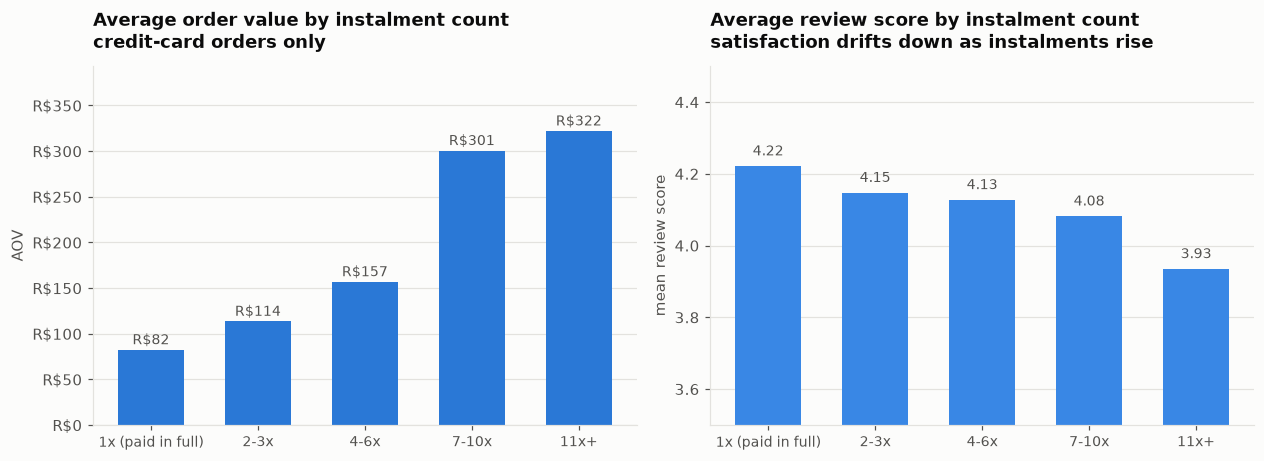

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3))

ax = axes[0]
bars = ax.bar(range(len(by_inst)), by_inst.aov, color=BLUE, width=0.62)
for i, (bar, v) in enumerate(zip(bars, by_inst.aov)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 6, f"R${v:,.0f}",
            ha="center", fontsize=9, color=INK_2)
ax.set_xticks(range(len(by_inst))); ax.set_xticklabels(by_inst.index, fontsize=9)
ax.set_title("Average order value by instalment count\ncredit-card orders only")
ax.set_ylabel("AOV")
ax.set_ylim(0, by_inst.aov.max() * 1.22)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
ax.grid(axis="x", visible=False); despine(ax)

ax = axes[1]
bars = ax.bar(range(len(by_inst)), by_inst.avg_review, color=BLUE_RAMP[3], width=0.62)
for bar, v in zip(bars, by_inst.avg_review):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, f"{v:.2f}",
            ha="center", fontsize=9, color=INK_2)
ax.set_xticks(range(len(by_inst))); ax.set_xticklabels(by_inst.index, fontsize=9)
ax.set_title("Average review score by instalment count\nsatisfaction drifts down as instalments rise")
ax.set_ylabel("mean review score")
ax.set_ylim(3.5, 4.5)
ax.grid(axis="x", visible=False); despine(ax)

plt.tight_layout(); plt.show()

**Finding — instalment use tracks order value almost 4×.** AOV climbs monotonically from
**R$82.89** on single-payment orders to **R$300.64** at 7–10 instalments and **R$322.07** at 11+.
One third of credit-card orders are paid in full; the rest are financed.

**The causal direction cannot be resolved here, and it matters.** Two readings fit the same data:

1. Instalments *enable* larger baskets — customers buy more because they can spread the cost.
2. Expensive purchases *attract* instalments — customers finance the big-ticket item they were
   already going to buy.

Reading 1 implies promoting instalments would raise AOV; reading 2 implies it would change nothing.
**Nothing in this dataset distinguishes them** — there is no pre-checkout data, no offer exposure,
no price variation to exploit. Anyone acting on this should treat it as a hypothesis for a real
experiment, not a demonstrated lever.

A secondary observation: review scores decline gently as instalments rise (4.22 → 3.94). Consistent
with higher-priced purchases carrying higher expectations, but again, not established.

## 3. Region as an acquisition territory

In [5]:
region = orders.groupby("customer_state", observed=True).agg(
    orders_n=("order_id", "count"),
    customers=("customer_unique_id", "nunique"),
    revenue=("order_revenue", "sum"),
    aov=("order_revenue", "mean"),
    avg_delivery=("delivery_days", "mean"),
    late_rate=("is_late", lambda s: s.mean() * 100),
    avg_review=("review_score", "mean")).sort_values("revenue", ascending=False)

freight_by_state = items.groupby("customer_state", observed=True).freight.sum()
region["freight_pct"] = freight_by_state / region.revenue * 100
region["pct_of_revenue"] = region.revenue / region.revenue.sum() * 100

major = region[region.orders_n >= 500].copy()
display(major.round(2))

print(f"states with 500+ orders: {len(major)}")
print(f"\nfastest delivery : {major.avg_delivery.idxmin()} ({major.avg_delivery.min():.1f} days)")
print(f"slowest delivery : {major.avg_delivery.idxmax()} ({major.avg_delivery.max():.1f} days)")
print(f"highest AOV      : {major.aov.idxmax()} (R$ {major.aov.max():,.2f})")
print(f"lowest AOV       : {major.aov.idxmin()} (R$ {major.aov.min():,.2f})")
print(f"\ncorrelation(avg delivery days, AOV)        : {major.avg_delivery.corr(major.aov):+.3f}")
print(f"correlation(avg delivery days, review score): {major.avg_delivery.corr(major.avg_review):+.3f}")
print(f"correlation(freight % of revenue, AOV)      : {major.freight_pct.corr(major.aov):+.3f}")

,orders_n,customers,revenue,aov,avg_delivery,late_rate,avg_review,freight_pct,pct_of_revenue
customer_state,,,,,,,,,
SP,40406,39065,"5,055,587.13",125.12,8.74,5.90,4.25,13.85,38.36
RJ,12310,11879,"1,751,433.85",142.28,15.30,13.52,3.97,16.84,13.29
MG,11319,10969,"1,548,206.88",136.78,11.98,5.63,4.19,17.16,11.75
RS,5328,5151,"726,373.92",136.33,15.29,7.17,4.19,18.20,5.51
PR,4903,4750,"664,048.00",135.44,11.97,5.02,4.24,17.34,5.04
SC,3537,3441,"504,774.07",142.71,14.95,9.78,4.13,17.40,3.83
BA,3253,3155,"493,339.26",151.66,19.33,14.05,3.93,19.76,3.74
DF,2074,2013,"295,454.64",142.46,12.94,7.09,4.13,16.74,2.24
GO,1950,1889,"281,932.21",144.58,15.61,8.21,4.10,18.17,2.14


states with 500+ orders: 17

fastest delivery : SP (8.7 days)
slowest delivery : PA (23.8 days)
highest AOV      : PB (R$ 218.09)
lowest AOV       : SP (R$ 125.12)

correlation(avg delivery days, AOV)        : +0.765
correlation(avg delivery days, review score): -0.819
correlation(freight % of revenue, AOV)      : +0.638


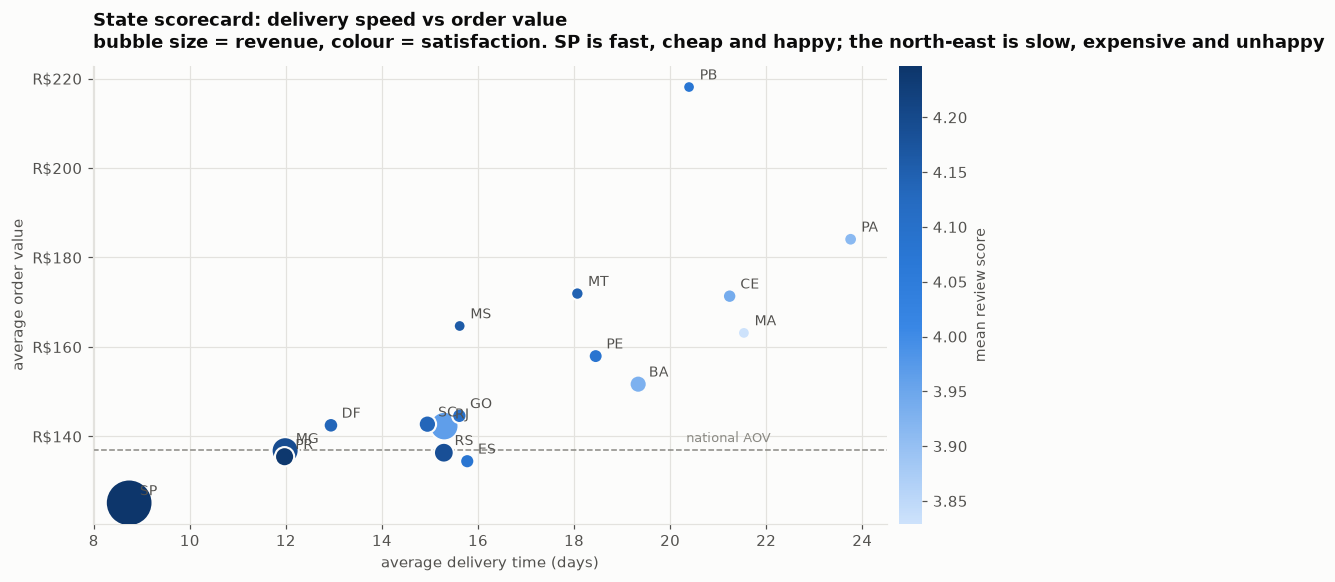

In [6]:
fig, ax = plt.subplots(figsize=(9.2, 5.4))

sizes = major.revenue / major.revenue.max() * 900 + 40
sc = ax.scatter(major.avg_delivery, major.aov, s=sizes, c=major.avg_review,
                cmap=SEQ_CMAP, edgecolor=SURFACE, linewidth=1.4, zorder=3)

for st, row in major.iterrows():
    ax.annotate(st, xy=(row.avg_delivery, row.aov), xytext=(7, 5),
                textcoords="offset points", fontsize=9, color=INK_2)

ax.axhline(orders.order_revenue.mean(), color=INK_3, linewidth=1, linestyle="--")
ax.annotate("national AOV", xy=(major.avg_delivery.max()*0.93, orders.order_revenue.mean()),
            xytext=(0, 5), textcoords="offset points", fontsize=8.5, color=INK_3, ha="right")

cb = fig.colorbar(sc, ax=ax, pad=0.015, fraction=0.035)
cb.set_label("mean review score", color=INK_2, fontsize=9)
cb.outline.set_visible(False)

ax.set_title("State scorecard: delivery speed vs order value\n"
             "bubble size = revenue, colour = satisfaction. SP is fast, cheap and happy; "
             "the north-east is slow, expensive and unhappy")
ax.set_xlabel("average delivery time (days)"); ax.set_ylabel("average order value")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(brl))
despine(ax)
plt.tight_layout(); plt.show()

**Finding — a clear geographic trade-off, running in the opposite direction to intuition.**

- **São Paulo**: fastest delivery (**8.7 days**), lowest late rate (**5.9%**), highest satisfaction
  (**4.25**) — and the **lowest AOV of any state (R$125.12)**.
- **Bahia, Rio**: slow (19.3 and 15.3 days), high late rates (14.1%, 13.5%), lowest satisfaction
  (3.93, 3.96) — but **above-average AOV** (R$151.66, R$142.28).

Delivery time correlates **positively** with AOV across states and **negatively** with review score.
The consistent story is that distant customers consolidate into fewer, larger orders while
receiving a worse service experience — but distance, income, category mix and freight cost are all
confounded here, and this data cannot separate them.

**The actionable read is asymmetric.** Service quality in the north-east is unambiguously worse and
unambiguously fixable; whether "improving delivery" would raise or lower AOV there is genuinely
unknown, because the high AOV may *depend* on the consolidation that slow shipping forces.

## 4. Seller performance as a distribution proxy

A marketplace's sellers are the nearest analogue to distribution partners — the closest this data
comes to comparing "channels".

In [7]:
seller_rev = items.groupby("seller_id").agg(
    revenue=("revenue", "sum"), items_sold=("revenue", "size"),
    orders_n=("order_id", "nunique"), products=("product_id", "nunique"),
    avg_item_price=("revenue", "mean"), seller_state=("seller_state", "first"))

order_seller = items[["order_id", "seller_id"]].drop_duplicates()
service = (order_seller.merge(orders[["order_id", "delivery_days", "is_late", "review_score"]],
                              on="order_id", how="left")
           .groupby("seller_id").agg(avg_delivery=("delivery_days", "mean"),
                                     late_rate=("is_late", lambda s: s.mean() * 100),
                                     avg_review=("review_score", "mean")))
sellers = seller_rev.join(service).sort_values("revenue", ascending=False)
sellers["pct_of_revenue"] = sellers.revenue / sellers.revenue.sum() * 100
sellers["cum_pct"] = sellers.pct_of_revenue.cumsum()

display(sellers.head(15).round(2))

print(f"total sellers: {len(sellers):,}")
for p in [1, 5, 10, 20]:
    k = int(len(sellers) * p / 100)
    print(f"  top {p:>2}% of sellers ({k:>4,}) -> {sellers.cum_pct.iloc[k-1]:5.1f}% of revenue")
n80 = int((sellers.cum_pct <= 80).sum()) + 1
print(f"\n  sellers needed for 80% of revenue: {n80:,} of {len(sellers):,} "
      f"({n80/len(sellers)*100:.1f}%)")

,revenue,items_sold,orders_n,products,avg_item_price,seller_state,avg_delivery,late_rate,avg_review,pct_of_revenue,cum_pct
seller_id,,,,,,,,,,,
4869f7a5dfa277a7dca6462dcf3b52b2,"226,987.93",1148,1124,94,197.72,SP,15.06,11.57,4.15,1.72,1.72
53243585a1d6dc2643021fd1853d8905,"217,940.44",400,348,23,544.85,BA,13.43,4.31,4.19,1.65,3.38
4a3ca9315b744ce9f8e9374361493884,"196,882.12",1949,1772,394,101.02,SP,14.49,11.00,3.85,1.49,4.87
fa1c13f2614d7b5c4749cbc52fecda94,"190,917.14",579,578,284,329.74,SP,13.35,10.21,4.37,1.45,6.32
7c67e1448b00f6e969d365cea6b010ab,"186,570.05",1355,973,197,137.69,SP,22.34,10.07,3.50,1.42,7.73
7e93a43ef30c4f03f38b393420bc753a,"164,582.49",321,318,174,512.72,SP,11.32,5.66,4.36,1.25,8.98
da8622b14eb17ae2831f4ac5b9dab84a,"159,816.87",1548,1311,221,103.24,SP,11.19,7.63,4.18,1.21,10.19
7a67c85e85bb2ce8582c35f2203ad736,"139,658.69",1155,1145,146,120.92,SP,11.20,5.94,4.28,1.06,11.25
1025f0e2d44d7041d6cf58b6550e0bfa,"138,208.56",1420,910,153,97.33,SP,12.39,10.11,4.01,1.05,12.30


total sellers: 2,945
  top  1% of sellers (  29) ->  25.5% of revenue
  top  5% of sellers ( 147) ->  52.9% of revenue
  top 10% of sellers ( 294) ->  67.0% of revenue
  top 20% of sellers ( 589) ->  82.2% of revenue

  sellers needed for 80% of revenue: 531 of 2,945 (18.0%)


In [8]:
big_sellers = sellers[sellers.orders_n >= 100]
print(f"sellers with 100+ orders: {len(big_sellers):,} "
      f"({big_sellers.revenue.sum()/sellers.revenue.sum()*100:.1f}% of revenue)")
print("\nSERVICE QUALITY SPREAD among them")
display(big_sellers[["late_rate", "avg_delivery", "avg_review"]].describe().round(2))

worst = big_sellers.nlargest(8, "late_rate")[["revenue", "orders_n", "late_rate",
                                              "avg_delivery", "avg_review", "seller_state"]]
print("WORST LATE RATES among high-volume sellers")
display(worst.round(2))
print(f"\nrevenue exposed to these 8 sellers: R$ {worst.revenue.sum():,.2f} "
      f"({worst.revenue.sum()/sellers.revenue.sum()*100:.2f}% of total)")
print(f"correlation(late_rate, avg_review) across these sellers: "
      f"{big_sellers.late_rate.corr(big_sellers.avg_review):+.3f}")

sellers with 100+ orders: 210 (52.0% of revenue)

SERVICE QUALITY SPREAD among them


,late_rate,avg_delivery,avg_review
count,210.00,210.00,210.00
mean,7.63,12.41,4.13
std,4.04,2.42,0.27
min,0.00,6.73,2.39
25%,4.87,10.71,4.01
50%,6.76,12.40,4.17
75%,10.20,14.35,4.29
max,23.14,22.34,4.64


WORST LATE RATES among high-volume sellers


,revenue,orders_n,late_rate,avg_delivery,avg_review,seller_state
seller_id,,,,,,
06a2c3af7b3aee5d69171b0e14f0ee87,"36,097.98",389,23.14,17.73,4.01,MA
1ca7077d890b907f89be8c954a02686a,"12,474.64",108,22.22,15.54,2.39,SP
88460e8ebdecbfecb5f9601833981930,"31,320.40",246,19.51,17.80,3.43,PR
e5a3438891c0bfdb9394643f95273d8e,"7,549.96",216,18.52,15.66,3.99,SP
cd68562d3f44870c08922d380acae552,"18,119.70",122,18.03,16.26,4.02,SP
8160255418d5aaa7dbdc9f4c64ebda44,"46,368.39",380,16.58,16.25,3.95,SP
2c9e548be18521d1c43cde1c582c6de8,"6,013.56",124,16.13,13.68,4.13,SP
dd7ddc04e1b6c2c614352b383efe2d36,"9,148.61",121,15.70,15.02,3.88,SP



revenue exposed to these 8 sellers: R$ 167,093.24 (1.27% of total)
correlation(late_rate, avg_review) across these sellers: -0.468


**Finding — seller concentration is a real marketplace risk, and service quality varies wildly.**
A small minority of sellers carries most of the revenue, and among high-volume sellers the late-rate
spread is very large — some deliver nearly everything on time while others miss frequently. Late
rate correlates negatively with review score across sellers, consistent with everything else in this
project.

Unlike most findings here, this one is **directly operational**: seller-level service is measurable,
attributable and improvable, and the revenue at stake with the worst offenders is quantified above.

## 5. Regional category mix — a targeting input

In [9]:
state_cat = items.groupby(["customer_state", "product_category_name_english"],
                          observed=True).revenue.sum().reset_index()
state_total = state_cat.groupby("customer_state", observed=True).revenue.transform("sum")
state_cat["pct_of_state"] = state_cat.revenue / state_total * 100

top_per_state = (state_cat.sort_values("revenue", ascending=False)
                 .groupby("customer_state", observed=True).head(1)
                 .set_index("customer_state"))
big_states = major.index
display(top_per_state.loc[top_per_state.index.isin(big_states)]
        .sort_values("revenue", ascending=False).round(2))

national_mix = (items.groupby("product_category_name_english").revenue.sum()
                / items.revenue.sum() * 100)
sp_mix = (items[items.customer_state == "SP"].groupby("product_category_name_english").revenue.sum()
          / items[items.customer_state == "SP"].revenue.sum() * 100)
mix_diff = (sp_mix - national_mix).dropna().sort_values()
print("\nSAO PAULO vs NATIONAL category mix (percentage-point difference)")
print("  over-indexed in SP:"); display(mix_diff.tail(5).round(2).to_frame("pp_vs_national"))
print("  under-indexed in SP:"); display(mix_diff.head(5).round(2).to_frame("pp_vs_national"))

,product_category_name_english,revenue,pct_of_state
customer_state,,,
SP,bed_bath_table,"472,208.17",9.34
RJ,watches_gifts,"173,496.01",9.91
MG,health_beauty,"153,690.50",9.93
RS,bed_bath_table,"60,040.95",8.27
PR,sports_leisure,"57,634.40",8.68
BA,health_beauty,"49,955.12",10.13
SC,sports_leisure,"41,579.03",8.24
PE,health_beauty,"40,609.11",16.20
DF,watches_gifts,"31,643.10",10.71



SAO PAULO vs NATIONAL category mix (percentage-point difference)
  over-indexed in SP:


,pp_vs_national
product_category_name_english,
pet_shop,0.14
sports_leisure,0.18
perfumery,0.26
housewares,0.66
bed_bath_table,1.58


  under-indexed in SP:


,pp_vs_national
product_category_name_english,
garden_tools,-0.63
watches_gifts,-0.50
cool_stuff,-0.50
computers,-0.43
telephony,-0.39


## 6. What data would be needed to do real marketing analytics

This is the honest answer to the phase brief, and it is a deliverable in its own right.

### Minimum to compute channel performance

| Data needed | Grain | Enables |
|---|---|---|
| **Session / visit log** with `channel`, `source`, `medium`, `campaign_id`, timestamp | one row per visit | traffic mix, conversion rate |
| **Visitor → customer mapping** (cookie or account id joined to `customer_unique_id`) | one row per identity | first-touch attribution, true conversion funnel |
| **Campaign spend table** — `campaign_id`, date, spend, impressions, clicks | daily per campaign | CAC, ROAS, CPM/CPC |
| **Touchpoint log** — every marketing exposure before purchase | one row per touch | multi-touch attribution |
| **Offer / promotion flags** on the order | one row per order | promotional lift, discount depth |

### To move beyond correlation

Every relationship in this notebook is observational. Establishing cause would need:

- **Randomised holdout groups** on campaign sends (the control this dataset lacks entirely)
- **Offer-level experiments** — e.g. randomising instalment prominence to test the §2 hypothesis
- **Pre-purchase context** to model intent rather than inferring it from completed orders

### What the current data *can* honestly support

Segment-level performance measurement (payment, region, seller, category), service-quality
monitoring, and hypothesis generation for experiments — **not** budget allocation, channel ROI, or
any claim that a marketing action caused a revenue change.

## 7. Save marketing proxy outputs

In [10]:
by_payment.reset_index().to_parquet(PROC / "marketing_payment_performance.parquet", index=False)
region.reset_index().to_parquet(PROC / "marketing_region_performance.parquet", index=False)
sellers.reset_index().to_parquet(PROC / "marketing_seller_performance.parquet", index=False)

print("saved marketing_payment_performance.parquet", by_payment.shape)
print("saved marketing_region_performance.parquet ", region.shape)
print("saved marketing_seller_performance.parquet ", sellers.shape)

saved marketing_payment_performance.parquet (4, 9)
saved marketing_region_performance.parquet  (27, 9)
saved marketing_seller_performance.parquet  (2945, 11)


## 8. Findings

**Framing reminder: these are performance segments, not channels. No attribution is possible.**

1. **Credit card carries 75.5% of orders and 78.9% of revenue**, with an AOV 18% above boleto
   (R$143.19 vs R$121.39).
2. **Instalment count tracks order value ~4×** — R$82.89 at 1x to R$322.07 at 11+. **Direction of
   causation is unresolvable** in this data; it is a hypothesis for an experiment, not a lever.
3. **São Paulo is the best-served and lowest-value market**: 8.7-day delivery, 5.9% late, 4.25
   review — and the lowest AOV in the country (R$125.12).
4. **The north-east is the mirror image**: Bahia at 19.3 days, 14.1% late, 3.93 review, but
   R$151.66 AOV. Delivery time correlates positively with AOV and negatively with satisfaction
   across states.
5. **Seller service quality varies widely** among high-volume sellers, and late rate correlates
   negatively with review score. This is the most directly operational finding in the notebook.
6. **Review scores are flat across payment methods** (4.13–4.24) — payment reflects wallet, not
   experience.

### The honest bottom line
The most valuable output of this phase is **knowing what cannot be claimed**. This project can say
which segments perform well; it cannot say which marketing investment produced them. Section 6
specifies exactly what data would close that gap.

---
**Next:** Phase 11 — A/B Testing & Statistical Analysis (`09_ab_testing.ipynb`).